### Import

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../'))

from environment.evaluation import *
from environment.data_loader import *
import random
from datetime import datetime

import itertools

import copy

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

### Get Config
Note that the below cell fetches all of the config data which is also used to train the models. This code will not run if you have not already completed a training simulation at some point with the same config parameters. If you have run the training already, you can set the `train_model` parameter in the `evaluation_congfig.yaml` file to `False` so that you can get the results without having to run the training again.

In [2]:
colors = {
    "DQN": 'darkorange',
    "REINFORCE": 'forestgreen',
    "ODT": 'blueviolet',
    "CMA": 'turquoise',
    "CMA-ES": 'turquoise'
}

season_colors = {
    "winter": 'blue',
    "spring": 'forestgreen',
    "summer": 'gold',
    "autumn": 'darkorange'
}

In [3]:
config_fname = 'config.yaml'

target_experiments = [2054, 2071] # Raw data to preprocess
exp_lists_preformatted = [
    '2000_2017.csv', '2018_2035.csv', # DQN
    '2036_2053.csv', '2054_2071.csv', # REINFORCE
    # '2072_2089.csv', '2090_2107.csv', # CMA
    # '2108_2125.csv', '2126_2143.csv', # ODT 1
] # Preprocessed data to use

file_path_for_processed_data = f'../../../../storage_1/metrics/formatted_experiment_data/part_6/'
base_path_metrics = f'../../../../storage_1/metrics/Exp_'

# Load Data

In [4]:
# Use preprocessed data if available

if len(exp_lists_preformatted) > 0:
    dataframes_raw = []
    
    # Load and combine datasets
    for existing_set in exp_lists_preformatted:
        loaded_dataset = pd.read_csv(f"{file_path_for_processed_data}/{existing_set}")

        print(f"Loaded {existing_set} - {len(loaded_dataset)} rows")

        # Combine datasets
        dataframes_raw.append(loaded_dataset)

    dataframes = pd.concat(dataframes_raw, ignore_index=True)

Loaded 2000_2017.csv - 180000 rows
Loaded 2018_2035.csv - 180000 rows
Loaded 2036_2053.csv - 170000 rows
Loaded 2054_2071.csv - 180000 rows


In [5]:
# Load and process raw data

def load_from_json_with_error_handling(filepath):
    try:
        return read_csv_data(filepath)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON from {filepath}: {e.msg} at line {e.lineno}, column {e.colno}")
        return None  # Handle the error and return None or an empty object

if len(exp_lists_preformatted) == 0:
    rows = []

    # Preformat and save dataset
    for target_experiment in range(target_experiments[0], (target_experiments[1] + 1)):
        print(f"Processing Experiment {target_experiment}: {target_experiment - target_experiments[0] + 1}/{target_experiments[1] - target_experiments[0] + 1}")

        # Load the config file
        c = load_config_file(f'../experiments/Exp_{target_experiment}/{config_fname}')

        # Get the hyperparameters
        nn_c = c['nn_hyperparameters']
        federated_c = c['federated_learning_settings']
        algo_c = c['algorithm_settings']
        env_c = c['environment_settings']

        # Extract important config data
        agg_count = federated_c['aggregation_count']
        algorithm = algo_c['algorithm']
        seed = env_c['seed']

        # Get the data
        train_path = f'{base_path_metrics}{target_experiment}/train/metrics'
        eval_path = f'{base_path_metrics}{target_experiment}/eval/metrics'
        episode_data_train = load_from_json_with_error_handling(f'{train_path}_agent_episode_level.csv')
        episode_data_eval = load_from_json_with_error_handling(f'{eval_path}_agent_episode_level.csv')

        # Calculate average rewards per aggregation/episode pair
        train_rewards = episode_data_train.groupby(['aggregation', 'episode'])['reward'].mean().reset_index()
        eval_rewards = episode_data_eval.groupby(['aggregation', 'episode'])['reward'].mean().reset_index()

        # Create dataframe entries for each aggregation/episode pair
        for _, row in train_rewards.iterrows():
            rows.append({
                'num_aggs': agg_count,
                'algorithm': algorithm,
                'seed': seed,
                'episode': row['episode'],
                'aggregation': row['aggregation'],
                'training_reward': row['reward'],
                'evaluation_reward': eval_rewards[
                    (eval_rewards['aggregation'] == row['aggregation']) & 
                    (eval_rewards['episode'] == row['episode'])
                ]['reward'].iloc[0]
            })

    # Convert rows to DataFrame here
    dataframes = pd.DataFrame(rows)

    # Save the preprocessed data to a CSV file
    dataframes.to_csv(f'{file_path_for_processed_data}/{target_experiments[0]}_{target_experiments[1]}.csv', index=False)

## Update reward to cumulative average

In [6]:
# The columns 'aggregation' and 'episode' will be merged into a single (absolute) episode index.
# We will store the results in a new DataFrame
cumulative_avg_reward_by_algorithm = []

group_keys = ['num_aggs', 'algorithm', 'seed']

non_decreasing_eval = False

for group_values, group_df in dataframes.groupby(group_keys):
    num_aggs = group_values[0]
    # Calculate the new absolute episode number: aggregation * episodes_per_agg + episode
    # Since aggregation and episode presumably start at 0
    # But if not, subtract min() to ensure 0-based
    min_agg = group_df['aggregation'].min()
    min_ep  = group_df['episode'].min()

    group_df = group_df.copy()
    group_df['absolute_episode'] = (group_df['aggregation'] - min_agg) * (10000 // num_aggs) + (group_df['episode'] - min_ep)

    # Sort by new absolute episode
    group_df_sorted = group_df.sort_values(['absolute_episode']).reset_index(drop=True)

    # Compute cumulative averages for training
    cum_train = group_df_sorted['training_reward'].expanding().mean()

    # Compute cumulative averages for evaluation with strict non-decreasing enforcement
    cum_eval = group_df_sorted['evaluation_reward'].expanding().mean().copy()

    if non_decreasing_eval:
        # Replace cum_eval with strictly monotonic non-decreasing values
        # This implementation ensures that for floating point noise, a very small drop never occurs
        max_so_far = cum_eval.iloc[0]
        cum_eval_fixed = [max_so_far]
        for v in cum_eval.iloc[1:]:
            if v >= max_so_far:
                max_so_far = v
            cum_eval_fixed.append(max_so_far)
        cum_eval = pd.Series(cum_eval_fixed, index=cum_eval.index)

    # Add these fields into the group data
    group_df_sorted['cumulative_avg_training_reward'] = cum_train
    group_df_sorted['cumulative_avg_evaluation_reward'] = cum_eval

    # Remove aggregation and (old) episode columns
    group_df_sorted = group_df_sorted.drop(columns=['aggregation', 'episode'])

    cumulative_avg_reward_by_algorithm.append(group_df_sorted)

# Concatenate all results together
cumulative_avg_reward_by_algorithm = pd.concat(cumulative_avg_reward_by_algorithm, ignore_index=True)


# Display Results

### Reward Metrics

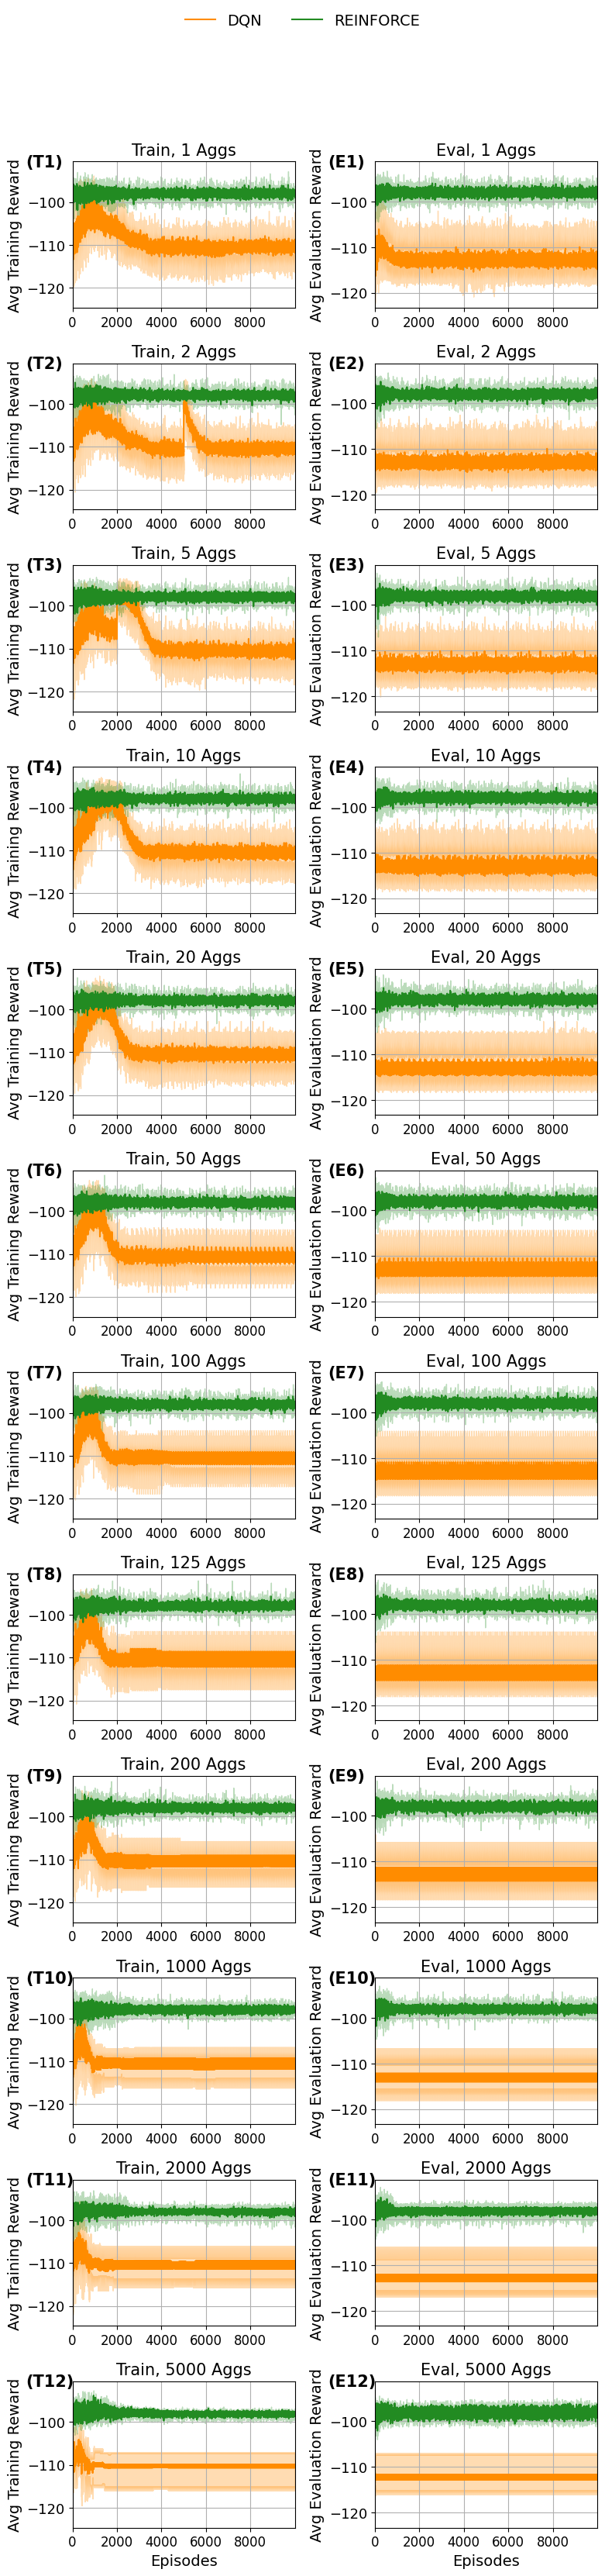

In [7]:
# Plot a 12x2 grid: each row is an aggregation level, columns are [Training, Evaluation] rewards
import matplotlib.pyplot as plt
import numpy as np

avg_reward_by_algorithm = copy.deepcopy(cumulative_avg_reward_by_algorithm)

# Prepare aggregation levels and plot structure
agg_levels_sorted = sorted(avg_reward_by_algorithm['num_aggs'].unique())
num_agg_levels = len(agg_levels_sorted)
nrows, ncols = num_agg_levels, 2  # 12x2 for 12 agg levels

# Set global font size
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 14, 
    'xtick.labelsize': 12, 
    'ytick.labelsize': 13, 
    'legend.fontsize': 13,
    'figure.titlesize': 17
})

fig, axes = plt.subplots(nrows, ncols, figsize=(8, 0.6 + 2.7*nrows), sharex=False, sharey='col')

if nrows == 1: # in case only 1 agg level, make axes 2d
    axes = axes.reshape((1, 2))

subplot_labels = {}
for i in range(nrows):
    subplot_labels[(i, 0)] = f"(T{i+1})"
    subplot_labels[(i, 1)] = f"(E{i+1})"

algorithm_handles = {}
algorithm_labels = {}
algorithms_added_train = set()
algorithms_added_eval  = set()

def subplots_visual(ax, title, label):
    ax.set_title(title)
    ax.text(
        -0.21, 1.05, label,
        transform=ax.transAxes,
        fontsize=15, fontweight='bold',
        va='top', ha='left'
    )

for row, agg_level in enumerate(agg_levels_sorted):
    # Select this aggregation level
    agg_data = avg_reward_by_algorithm[
        avg_reward_by_algorithm['num_aggs'] == agg_level
    ].copy()
    
    #--- TRAINING REWARD PLOT (left column) ---
    ax_train = axes[row, 0]
    subplots_visual(ax_train, f"Train, {agg_level} Aggs", subplot_labels[(row, 0)])

    for algo in agg_data['algorithm'].unique():
        algo_data = agg_data[agg_data['algorithm'] == algo]
        min_tr = algo_data.groupby('absolute_episode')['training_reward'].min()
        max_tr = algo_data.groupby('absolute_episode')['training_reward'].max()
        mean_tr = algo_data.groupby('absolute_episode')['training_reward'].mean()

        fill = ax_train.fill_between(
            min_tr.index, min_tr.values, max_tr.values,
            color=colors[algo], alpha=0.3
        )
        line, = ax_train.plot(
            mean_tr.index, mean_tr.values,
            color=colors[algo], label=algo
        )
        if algo not in algorithms_added_train:
            algorithm_handles[algo] = line
            algorithm_labels[algo] = ('CMA-ES' if algo == 'CMA' else algo)
            algorithms_added_train.add(algo)

    ax_train.grid(True)
    ax_train.set_xlim([agg_data['absolute_episode'].min(), agg_data['absolute_episode'].max()])
    if row == 0:
        ax_train.set_title(f"Train, {agg_level} Aggs")
    if row == nrows-1:
        ax_train.set_xlabel('Episodes')
    if 0 == 0:
        ax_train.set_ylabel('Avg Training Reward')

    #--- EVALUATION REWARD PLOT (right column) ---
    ax_eval = axes[row, 1]
    subplots_visual(ax_eval, f"Eval, {agg_level} Aggs", subplot_labels[(row, 1)])

    for algo in agg_data['algorithm'].unique():
        algo_data = agg_data[agg_data['algorithm'] == algo]
        min_ev = algo_data.groupby('absolute_episode')['evaluation_reward'].min()
        max_ev = algo_data.groupby('absolute_episode')['evaluation_reward'].max()
        mean_ev = algo_data.groupby('absolute_episode')['evaluation_reward'].mean()

        fill = ax_eval.fill_between(
            min_ev.index, min_ev.values, max_ev.values,
            color=colors[algo], alpha=0.3
        )
        line, = ax_eval.plot(
            mean_ev.index, mean_ev.values,
            color=colors[algo], label=algo
        )
        if algo not in algorithms_added_eval:
            # only gather ONE legend entry per algorithm for evaluation column
            algorithm_handles[f'eval_{algo}'] = line
            algorithm_labels[f'eval_{algo}'] = ('CMA-ES' if algo == 'CMA' else algo)
            algorithms_added_eval.add(algo)

    ax_eval.grid(True)
    ax_eval.set_xlim([agg_data['absolute_episode'].min(), agg_data['absolute_episode'].max()])
    if row == nrows-1:
        ax_eval.set_xlabel('Episodes')
    if 1 == 1:
        ax_eval.set_ylabel('Avg Evaluation Reward')

# Set y-limits for all train (left col) and all eval (right col) plots to assist comparison
train_min = avg_reward_by_algorithm['training_reward'].min()
train_max = avg_reward_by_algorithm['training_reward'].max()
eval_min = avg_reward_by_algorithm['evaluation_reward'].min()
eval_max = avg_reward_by_algorithm['evaluation_reward'].max()
for ax in axes[:,0]:
    ax.set_ylim([train_min-1, train_max+1])
for ax in axes[:,1]:
    ax.set_ylim([eval_min-1, eval_max+1])

# Legend: Above all subplots
# Use the union of algorithms from both columns
unique_labels = []
unique_lines = []
legend_algos = sorted(set(algorithm_labels.values()), key=str.lower)
for algo in legend_algos:
    # Use train handles preferentially, fallback to eval
    found = False
    for handle_algo, label in algorithm_labels.items():
        if label == algo:
            unique_labels.append(label)
            unique_lines.append(algorithm_handles[handle_algo])
            found = True
            break
    if not found:  # shouldn't ever happen, but safety
        continue

fig.legend(unique_lines, unique_labels,
           loc='upper center',
           ncol=len(unique_labels),
           bbox_to_anchor=(0.5, 1.01),
           frameon=False,
           fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('./figures/agg_level_train_eval_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


### Training Duration Metrics